# MFC Experiment — Statistical Analysis
## Adaptive Feedback Control of a Multi-Input Microbial Fuel Cell
### Jonathan D. Miller · Boston University MSE 2026

Reproduces every statistical result in the thesis (Chapter 4), including
all values in **Table 4.12** (cross-experiment Welch's t-test results).

| Exp | Start (EST) | End (EST) | Firmware | MFC sensor | Source |
|-----|-------------|-----------|----------|-----------|--------|
| 1 | Mar 29 11:05 PM | Mar 31 9:12 AM | v13 | Relay / main Arduino | Experiment_1.zip |
| 2 | Apr 3 2:56 AM | Apr 4 8:38 AM | v21 | Chickie Arduino | Experiment_2.zip |
| 3 | Apr 4 4:00 PM | Apr 5 4:00 PM | v22 | Chickie Arduino | Experiment_3.zip |

**All sensors for every experiment are loaded from the experiment zip files.**
EST = UTC - 5. All timestamps stored as UTC.

**Key caveats:**
- ORP sensor recalibrated 2 April 2026. Exps 1-2 and 3-4 ORP not directly comparable.
- Exp 1 MFC has spike readings >600 mV filtered at load time.
- Exp 3 MFC has ~40 mV upward trend over 24 h; pooled result is window-sensitive.
- Large n inflates significance (serial correlation within phases).
  Effect sizes (Delta) and 95% CI are more informative than p-values.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import zipfile
from scipy import stats
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
print('OK')


OK


## 2. Data Loading

Every experiment's sensors are loaded from its zip file.
This guarantees each experiment uses its own correctly-windowed stressState.

- **Exps 1-2** MFC: `cloud_MFC_mV` — relay-isolated on main Arduino.
- **Exps 2-3** MFC: `mfc_voltage-MFC_Voltage` — Chickie Arduino.
- Exp 2 MFC spikes >600 mV filtered at load time (hardware noise).


In [2]:
ZIP_DIR = '/mnt/user-data/outputs/'

def load_from_zip(zip_path, fname_fragment):
    with zipfile.ZipFile(zip_path) as zf:
        matches = [n for n in zf.namelist() if fname_fragment in n and n.endswith('.csv')]
        if not matches:
            return pd.DataFrame(columns=['time','value'])
        with zf.open(matches[0]) as f:
            df = pd.read_csv(f)
    df['time'] = pd.to_datetime(df['time'], utc=True)
    return df.sort_values('time').reset_index(drop=True)[['time','value']]

# Fragment to search for MFC file varies by experiment
MFC_FRAGMENT = {
    1: 'cloud_MFC_mV',     # relay on main Arduino (Mar 30-31)
    2: 'mfc_voltage',      # Chickie Arduino (Apr 3-4)
    3: 'mfc_voltage',      # Chickie Arduino (Apr 4-5)
}

zip_data = {}
for exp in [1, 2, 3]:
    zpath = f'{ZIP_DIR}Experiment_{exp}.zip'
    state = load_from_zip(zpath, 'stressState')
    state = state.dropna(subset=['value']).reset_index(drop=True)
    orp   = load_from_zip(zpath, 'ORP_mV')
    ph    = load_from_zip(zpath, 'cloud_pH')
    ec    = load_from_zip(zpath, 'EC_mS')
    mfc   = load_from_zip(zpath, MFC_FRAGMENT[exp])
    if exp == 1:
        mfc = mfc[mfc['value'] <= 600].reset_index(drop=True)  # remove spikes
    zip_data[exp] = {'state': state, 'orp': orp, 'ph': ph, 'ec': ec, 'mfc': mfc}

print(f'  {"Exp":>3}  {"state":>7}  {"orp":>8}  {"ph":>8}  {"ec":>8}  {"mfc":>8}')
print('  ' + '-'*50)
for exp in [1,2,3]:
    d = zip_data[exp]
    print(f'  {exp:>3}  {len(d["state"]):>7,}  {len(d["orp"]):>8,}  '
          f'{len(d["ph"]):>8,}  {len(d["ec"]):>8,}  {len(d["mfc"]):>8,}')


  Exp    state       orp        ph        ec       mfc
  --------------------------------------------------
    1       30    20,443    19,320    24,820    15,604
    2       10    21,719    19,078    19,465    42,391
    3       16    16,896    14,700    14,912    33,611


## 3. Condition Labeling

Each sensor reading is assigned the most recent prior `stressState` value
using `pd.merge_asof` (backward merge). Readings before the first state entry
receive NaN and are dropped. Only `LQR` and `BASELINE` are kept.


In [3]:
def label_sensor(sensor_df, state_df):
    if len(sensor_df) == 0 or len(state_df) == 0:
        return pd.DataFrame(columns=['time','value','condition'])
    merged = pd.merge_asof(
        sensor_df.sort_values('time').reset_index(drop=True),
        state_df.sort_values('time').reset_index(drop=True).rename(columns={'value':'condition'}),
        on='time', direction='backward'
    )
    merged = merged.dropna(subset=['condition'])
    return merged[merged['condition'].isin(['LQR','BASELINE'])].copy().reset_index(drop=True)

labeled = {}
for exp in [1, 2, 3]:
    state = zip_data[exp]['state']
    labeled[exp] = {key: label_sensor(zip_data[exp][key], state)
                    for key in ['orp','ph','ec','mfc']}

print(f'  {"Exp":>3}  {"Sensor":>6}  {"LQR n":>8}  {"BASE n":>8}')
print('  ' + '-'*32)
for exp in [1,2,3]:
    for key in ['orp','ph','mfc']:
        df = labeled[exp][key]
        n_lqr  = (df['condition']=='LQR').sum()
        n_base = (df['condition']=='BASELINE').sum()
        if n_lqr + n_base > 0:
            print(f'  {exp:>3}  {key:>6}  {n_lqr:>8,}  {n_base:>8,}')


  Exp  Sensor     LQR n    BASE n
  --------------------------------
    1     orp     6,718     6,653
    1      ph     6,286     6,317
    1     mfc     4,843     4,651
    2     orp     4,469     3,076
    2      ph     3,965     2,622
    2     mfc     8,574     5,671
    3     orp     5,912     5,113
    3      ph     5,216     4,353
    3     mfc    11,569    10,234


## 4. Welch's t-tests — Raw Readings

`scipy.stats.ttest_ind(equal_var=False)`. One-sided p-values.
95% CI via Welch-Satterthwaite df.

H1: MFC LQR > BASE;  ORP LQR < BASE (more negative);  pH LQR > BASE.


In [4]:
def welch_test(df, alternative='greater'):
    if 'condition' not in df.columns or len(df) == 0:
        return None
    lqr  = df[df['condition']=='LQR']['value'].dropna().values
    base = df[df['condition']=='BASELINE']['value'].dropna().values
    if len(lqr) < 2 or len(base) < 2:
        return None
    lqr_mean,  base_mean = lqr.mean(),      base.mean()
    lqr_std,   base_std  = lqr.std(ddof=1), base.std(ddof=1)
    delta = lqr_mean - base_mean
    n1, n2 = len(lqr), len(base)
    t_stat, p_two = ttest_ind(lqr, base, equal_var=False)
    if alternative == 'greater':
        p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
    elif alternative == 'less':
        p_one = p_two/2 if t_stat < 0 else 1 - p_two/2
    else:
        p_one = p_two
    se    = np.sqrt(lqr_std**2/n1 + base_std**2/n2)
    num   = (lqr_std**2/n1 + base_std**2/n2)**2
    denom = (lqr_std**2/n1)**2/(n1-1) + (base_std**2/n2)**2/(n2-1)
    df_ws = num/denom
    t_crit = stats.t.ppf(0.975, df_ws)
    ci_lo, ci_hi = delta - t_crit*se, delta + t_crit*se
    sig = '***' if p_one<0.001 else ('**' if p_one<0.01 else ('*' if p_one<0.05 else 'ns'))
    return dict(n_lqr=n1, n_base=n2,
                lqr_mean=lqr_mean, lqr_std=lqr_std,
                base_mean=base_mean, base_std=base_std,
                delta=delta, ci_lo=ci_lo, ci_hi=ci_hi,
                t_stat=t_stat, df=df_ws, p_val=p_one, sig=sig)

SENSORS = [
    ('mfc', 'MFC Voltage (mV)', 'greater'),
    ('orp', 'ORP (mV)',         'less'),
    ('ph',  'pH',               'greater'),
]

results = {}
for exp in [1,2,3]:
    results[exp] = {}
    for key, label, alt in SENSORS:
        r = welch_test(labeled[exp][key], alternative=alt)
        if r:
            results[exp][key] = r

print(f'Computed {sum(len(v) for v in results.values())} tests.')


Computed 9 tests.


## 5. Table 4.12 — Cross-Experiment Welch's t-test Results

In [5]:
hdr = (f'  {"Metric":<18} {"Exp":>3}  {"LQR mean+/-SD":>18}  {"Base mean+/-SD":>18}'
       f'  {"Delta":>7}  {"95% CI":>22}  {"p":>14}')
print('=' * len(hdr))
print(hdr)
print('=' * len(hdr))
for key, label, alt in SENSORS:
    first = True
    for exp in [1,2,3]:
        r = results[exp].get(key)
        if not r: continue
        lqr_s  = f'{r["lqr_mean"]:.2f} +/- {r["lqr_std"]:.2f}'
        base_s = f'{r["base_mean"]:.2f} +/- {r["base_std"]:.2f}'
        ci_s   = f'[{r["ci_lo"]:+.3f}, {r["ci_hi"]:+.3f}]'
        p_s    = ('p < 0.001 ' + r['sig']) if r['p_val'] < 0.001 else f'p = {r["p_val"]:.4f} {r["sig"]}'
        ml = label if first else ''
        first = False
        print(f'  {ml:<18} {exp:>3}  {lqr_s:>18}  {base_s:>18}'
              f'  {r["delta"]:>+7.3f}  {ci_s:>22}  {p_s:>14}')
    print('  ' + '-'*(len(hdr)-2))
print()
print('H1: MFC = LQR>BASE;  ORP = LQR<BASE;  pH = LQR>BASE')
print('MFC Exp 1: relay-isolated main Arduino (cloud_MFC_mV). Exp 1 spikes >600 mV removed.')
print('ORP Exp 1 vs 3-4 NOT comparable (sensor recalibrated 2 Apr 2026).')
print('Exp 1 MFC BASELINE>LQR: preliminary (time-based acid, variable starting pH).')
print('Exp 3 MFC: ~40 mV upward trend over 24 h; result is window-sensitive.')


  Metric             Exp       LQR mean+/-SD      Base mean+/-SD    Delta                  95% CI               p
  MFC Voltage (mV)     1    149.91 +/- 34.76    142.48 +/- 32.75   +7.426        [+6.068, +8.784]   p < 0.001 ***
                       2      81.95 +/- 6.96      81.11 +/- 5.22   +0.845        [+0.645, +1.046]   p < 0.001 ***
                       3    141.25 +/- 15.36    140.87 +/- 14.69   +0.375        [-0.024, +0.774]    p = 0.0328 *
  ---------------------------------------------------------------------------------------------------------------
  ORP (mV)             1   -193.95 +/- 30.38   -184.99 +/- 31.68   -8.959       [-10.011, -7.906]   p < 0.001 ***
                       2   -536.23 +/- 58.99   -536.02 +/- 65.62   -0.209        [-3.102, +2.685]   p = 0.4438 ns
                       3   -536.07 +/- 44.19   -520.47 +/- 44.96  -15.597      [-17.267, -13.927]   p < 0.001 ***
  --------------------------------------------------------------------------------------

## 6. Full Numeric Summary (all test statistics)

In [6]:
rows = []
for key, label, alt in SENSORS:
    for exp in [1,2,3]:
        r = results[exp].get(key)
        if not r: continue
        rows.append({'Metric': label, 'Exp': exp,
                     'n_LQR': r['n_lqr'], 'n_BASE': r['n_base'],
                     'LQR_mean': round(r['lqr_mean'],4), 'LQR_SD': round(r['lqr_std'],4),
                     'BASE_mean': round(r['base_mean'],4), 'BASE_SD': round(r['base_std'],4),
                     'Delta': round(r['delta'],4),
                     'CI_lo': round(r['ci_lo'],4), 'CI_hi': round(r['ci_hi'],4),
                     't_stat': round(r['t_stat'],4), 'df_WS': round(r['df'],1),
                     'p_one_sided': round(r['p_val'],6), 'sig': r['sig']})
print(pd.DataFrame(rows).to_string(index=False))


          Metric  Exp  n_LQR  n_BASE  LQR_mean  LQR_SD  BASE_mean  BASE_SD    Delta    CI_lo    CI_hi   t_stat      df_WS  p_one_sided sig
MFC Voltage (mV)    1   4843    4651  149.9094 34.7612   142.4832  32.7492   7.4263   6.0680   8.7845  10.7178  9488.5000       0.0000 ***
MFC Voltage (mV)    2   8574    5671   81.9516  6.9600    81.1062   5.2230   0.8455   0.6450   1.0459   8.2666 14019.7000       0.0000 ***
MFC Voltage (mV)    3  11569   10234  141.2491 15.3601   140.8740  14.6927   0.3751  -0.0241   0.7744   1.8417 21668.3000       0.0328   *
        ORP (mV)    1   6718    6653 -193.9468 30.3816  -184.9880  31.6781  -8.9588 -10.0111  -7.9064 -16.6869 13333.7000       0.0000 ***
        ORP (mV)    2   4469    3076 -536.2260 58.9936  -536.0172  65.6247  -0.2088  -3.1025   2.6848  -0.1415  6139.8000       0.4438  ns
        ORP (mV)    3   5912    5113 -536.0720 44.1911  -520.4749  44.9612 -15.5971 -17.2669 -13.9273 -18.3092 10739.3000       0.0000 ***
              pH    1   628

## 7. Segment-Level Analysis (pseudoreplication-corrected)

The statistically correct unit of analysis is the **complete phase segment**
(one LQR or BASELINE run), not the individual 5-second reading.
With 2-8 segments per condition per experiment, the test is underpowered but valid.


In [7]:
def segment_means(labeled_df, min_readings=30):
    df = labeled_df[['time','value','condition']].copy().sort_values('time').reset_index(drop=True)
    if len(df) == 0:
        return pd.DataFrame(columns=['condition','n','mean','std','seg_start'])
    df['block'] = (df['condition'] != df['condition'].shift()).cumsum()
    segs = []
    for (cond, blk), grp in df.groupby(['condition','block'], sort=False):
        if len(grp) >= min_readings:
            segs.append({'condition': cond, 'n': len(grp),
                         'mean': grp['value'].mean(), 'std': grp['value'].std(ddof=1),
                         'seg_start': grp['time'].iloc[0].tz_convert('America/New_York').strftime('%b %d %H:%M')})
    return pd.DataFrame(segs) if segs else pd.DataFrame(columns=['condition','n','mean','std','seg_start'])

print('Segment-level Welch tests (unit = phase-segment mean):')
print()
for key, label, alt in SENSORS:
    print(f'{label}:')
    for exp in [1,2,3]:
        segs = segment_means(labeled[exp][key])
        if len(segs) == 0: continue
        lqr_s  = segs[segs['condition']=='LQR']['mean'].values
        base_s = segs[segs['condition']=='BASELINE']['mean'].values
        delta_s = lqr_s.mean() - base_s.mean() if len(lqr_s) and len(base_s) else float('nan')
        if len(lqr_s) >= 2 and len(base_s) >= 2:
            t_stat, p_two = ttest_ind(lqr_s, base_s, equal_var=False)
            p_one = p_two/2 if (alt=='greater' and t_stat>0) or (alt=='less' and t_stat<0) else 1-p_two/2
            sig   = '***' if p_one<0.001 else ('*' if p_one<0.05 else 'ns')
            print(f'  Exp {exp}: LQR={lqr_s.mean():.3f}(n={len(lqr_s)})  '
                  f'BASE={base_s.mean():.3f}(n={len(base_s)})  '
                  f'Delta={delta_s:+.4f}  t={t_stat:.3f}  p={p_one:.4f} {sig}')
        else:
            print(f'  Exp {exp}: n_lqr={len(lqr_s)}, n_base={len(base_s)} -- insufficient.  Delta={delta_s:+.4f}')
    print()


Segment-level Welch tests (unit = phase-segment mean):

MFC Voltage (mV):
  Exp 1: LQR=149.290(n=7)  BASE=143.462(n=7)  Delta=+5.8280  t=0.310  p=0.3809 ns
  Exp 2: LQR=81.853(n=3)  BASE=81.015(n=2)  Delta=+0.8371  t=0.123  p=0.4557 ns
  Exp 3: LQR=140.979(n=4)  BASE=143.832(n=4)  Delta=-2.8527  t=-0.229  p=0.5866 ns

ORP (mV):
  Exp 1: LQR=-195.554(n=7)  BASE=-187.950(n=7)  Delta=-7.6041  t=-0.437  p=0.3348 ns
  Exp 2: LQR=-537.638(n=3)  BASE=-535.942(n=2)  Delta=-1.6963  t=-0.025  p=0.4913 ns
  Exp 3: LQR=-536.021(n=4)  BASE=-528.795(n=4)  Delta=-7.2257  t=-0.242  p=0.4085 ns

pH:


  Exp 1: LQR=7.182(n=7)  BASE=7.033(n=7)  Delta=+0.1489  t=2.980  p=0.0093 *
  Exp 2: LQR=7.159(n=3)  BASE=6.926(n=2)  Delta=+0.2333  t=39.320  p=0.0003 ***
  Exp 3: LQR=7.160(n=4)  BASE=7.044(n=4)  Delta=+0.1164  t=3.850  p=0.0102 *



## 8. Segment Detail — Phase Means for pH and MFC

In [8]:
for key, label in [('ph','pH'), ('mfc','MFC Voltage (mV)')]:
    print(f'{label} -- per-segment means')
    print(f'  {"Exp":>3}  {"Condition":>10}  {"Start (EST)":>14}  {"n":>6}  {"Mean":>8}  {"SD":>7}')
    print('  ' + '-'*56)
    for exp in [1,2,3]:
        segs = segment_means(labeled[exp][key])
        for _, row in segs.sort_values('seg_start').iterrows():
            print(f'  {exp:>3}  {row["condition"]:>10}  {row["seg_start"]:>14}'
                  f'  {row["n"]:>6,}  {row["mean"]:>8.3f}  {row["std"]:>7.3f}')
    print()


pH -- per-segment means
  Exp   Condition     Start (EST)       n      Mean       SD
  --------------------------------------------------------
    1    BASELINE    Mar 30 00:05     994     7.133    0.150
    1         LQR    Mar 30 02:05     963     7.222    0.125
    1    BASELINE    Mar 30 04:05     967     7.109    0.196
    1         LQR    Mar 30 06:05     945     7.224    0.121
    1    BASELINE    Mar 30 08:05     941     7.131    0.191
    1         LQR    Mar 30 10:05     913     7.221    0.083
    1    BASELINE    Mar 30 12:05     993     7.018    0.107
    1         LQR    Mar 30 14:05     997     7.203    0.117
    1    BASELINE    Mar 30 16:05     870     7.101    0.117
    1         LQR    Mar 30 18:05     684     7.122    0.151
    1    BASELINE    Mar 30 23:48     902     6.942    0.156
    1         LQR    Mar 31 02:14     812     7.152    0.141
    1    BASELINE    Mar 31 05:02     650     6.801    0.167
    1         LQR    Mar 31 07:17     972     7.131    0.132
  

    3         LQR    Apr 04 20:28   1,323     7.137    0.127
    3    BASELINE    Apr 04 22:44   1,218     7.044    0.095
    3         LQR    Apr 05 01:03   1,239     7.149    0.124
    3    BASELINE    Apr 05 03:26   1,197     7.095    0.125
    3         LQR    Apr 05 05:51   1,326     7.178    0.150
    3    BASELINE    Apr 05 08:18   1,297     7.071    0.125
    3         LQR    Apr 05 12:33   1,328     7.176    0.138
    3    BASELINE    Apr 05 15:02     641     6.965    0.119

MFC Voltage (mV) -- per-segment means
  Exp   Condition     Start (EST)       n      Mean       SD
  --------------------------------------------------------


    1    BASELINE    Mar 30 00:05     776   137.503    2.201
    1         LQR    Mar 30 02:05     699   139.401    2.678
    1    BASELINE    Mar 30 04:05     719   127.880    1.267
    1         LQR    Mar 30 06:05     705   134.047    2.632
    1    BASELINE    Mar 30 08:05     638   127.456    2.499
    1         LQR    Mar 30 10:05     635   136.456    3.779
    1    BASELINE    Mar 30 12:05     704   130.618    2.588
    1         LQR    Mar 30 14:05     674   108.968   15.348
    1    BASELINE    Mar 30 16:05     646   101.164    2.477
    1         LQR    Mar 30 18:05     667   152.629   27.970
    1    BASELINE    Mar 30 23:48     681   209.001    2.947
    1         LQR    Mar 31 02:14     716   221.158    2.790
    1    BASELINE    Mar 31 05:02     487   170.611    9.796
    1         LQR    Mar 31 07:17     747   152.369    2.109
    2         LQR    Apr 03 05:56   2,757    76.037    1.396
    2    BASELINE    Apr 03 11:33   2,784    76.019    1.392
    2         LQR    Apr

    3         LQR    Apr 04 20:28   2,813   127.128    1.486


    3    BASELINE    Apr 04 22:44   2,874   124.349    2.358
    3         LQR    Apr 05 01:03   2,851   129.177    3.316
    3    BASELINE    Apr 05 03:26   2,871   134.835    4.187
    3         LQR    Apr 05 05:51   2,953   143.482    5.140
    3    BASELINE    Apr 05 08:18   3,017   150.065    4.365
    3         LQR    Apr 05 12:33   2,952   164.131    5.107
    3    BASELINE    Apr 05 15:02   1,472   166.080    1.963



## 9. ORP Trend Analysis

Linear slope (mV/min) within each phase. Negative = more reducing over time.
Only Exps 2-3 are directly comparable (recalibrated sensor).


In [9]:
def orp_slopes(labeled_orp_df):
    df = labeled_orp_df[['time','value','condition']].copy().sort_values('time').reset_index(drop=True)
    if len(df) == 0:
        return pd.DataFrame(columns=['condition','slope_mV_per_min','r2','n','duration_min','start_orp','end_orp','seg_start'])
    df['block'] = (df['condition'] != df['condition'].shift()).cumsum()
    rows = []
    for (cond, blk), grp in df.groupby(['condition','block'], sort=False):
        if len(grp) < 30: continue
        t_min = (grp['time'] - grp['time'].iloc[0]).dt.total_seconds() / 60.0
        slope, _, r, _, _ = stats.linregress(t_min, grp['value'])
        rows.append({'condition': cond, 'slope_mV_per_min': slope, 'r2': r**2,
                     'n': len(grp), 'duration_min': t_min.max(),
                     'start_orp': grp['value'].iloc[0], 'end_orp': grp['value'].iloc[-1],
                     'seg_start': grp['time'].iloc[0].tz_convert('America/New_York').strftime('%b %d %H:%M')})
    return pd.DataFrame(rows)

print(f'  {"Exp":>4}  {"Cond":>10}  {"Slope mV/min":>13}  {"R2":>6}  {"Dur":>9}  {"Start":>10}  {"End":>8}  Start')
print('  ' + '-'*88)
all_slopes = {}
for exp in [1,2,3]:
    sl = orp_slopes(labeled[exp]['orp'])
    all_slopes[exp] = sl
    for _, r in sl.iterrows():
        print(f'  {exp:>4}  {r["condition"]:>10}  {r["slope_mV_per_min"]:>+13.4f}'
              f'  {r["r2"]:>6.3f}  {r["duration_min"]:>8.1f}m'
              f'  {r["start_orp"]:>+10.1f}  {r["end_orp"]:>+8.1f}  {r["seg_start"]}')
print()
print('Exps 2-3 mean slopes (recalibrated sensor):')
for exp in [2,3]:
    sl = all_slopes[exp]
    for cond in ['LQR','BASELINE']:
        sub = sl[sl['condition']==cond]
        if len(sub):
            print(f'  Exp {exp} {cond:>10}: {sub["slope_mV_per_min"].mean():+.4f} mV/min  (n={len(sub)})')


   Exp        Cond   Slope mV/min      R2        Dur       Start       End  Start
  ----------------------------------------------------------------------------------------
     1    BASELINE        -0.8088   0.796      89.9m       -82.4    -175.9  Mar 30 00:05
     1         LQR        -0.1519   0.406      89.8m      -155.7    -165.4  Mar 30 02:05
     1    BASELINE        +0.1362   0.304      89.8m      -162.2    -158.9  Mar 30 04:05
     1         LQR        -0.1915   0.525      89.8m      -149.3    -171.0  Mar 30 06:05
     1    BASELINE        +0.0131   0.005      89.9m      -181.5    -166.2  Mar 30 08:05
     1         LQR        -0.1111   0.306      89.8m      -167.0    -178.3  Mar 30 10:05
     1    BASELINE        -0.0166   0.009      89.8m      -175.9    -185.5  Mar 30 12:05
     1         LQR        -0.1448   0.415      89.9m      -188.7    -190.4  Mar 30 14:05
     1    BASELINE        -0.1607   0.404      89.9m      -199.2    -193.6  Mar 30 16:05
     1         LQR        

## 10. Exp 4 MFC — Time Trend and Paired Analysis

MFC rises ~40 mV over 24 h (biofilm maturation). Because LQR always precedes
BASELINE within each cycle, within-cycle paired differences are the correct comparison.


Exp 3 MFC per segment:
condition    seg_start     mean    std    n
      LQR Apr 04 20:28 127.1278 1.4863 2813
 BASELINE Apr 04 22:44 124.3488 2.3578 2874
      LQR Apr 05 01:03 129.1771 3.3164 2851
 BASELINE Apr 05 03:26 134.8350 4.1874 2871
      LQR Apr 05 05:51 143.4820 5.1404 2953
 BASELINE Apr 05 08:18 150.0645 4.3651 3017
      LQR Apr 05 12:33 164.1308 5.1068 2952
 BASELINE Apr 05 15:02 166.0801 1.9633 1472



Within-cycle LQR - BASE: ['+2.8', '-5.7', '-6.6', '-1.9']
Mean paired diff: -2.85 mV
Paired t-test: t=-1.341  p=0.2724


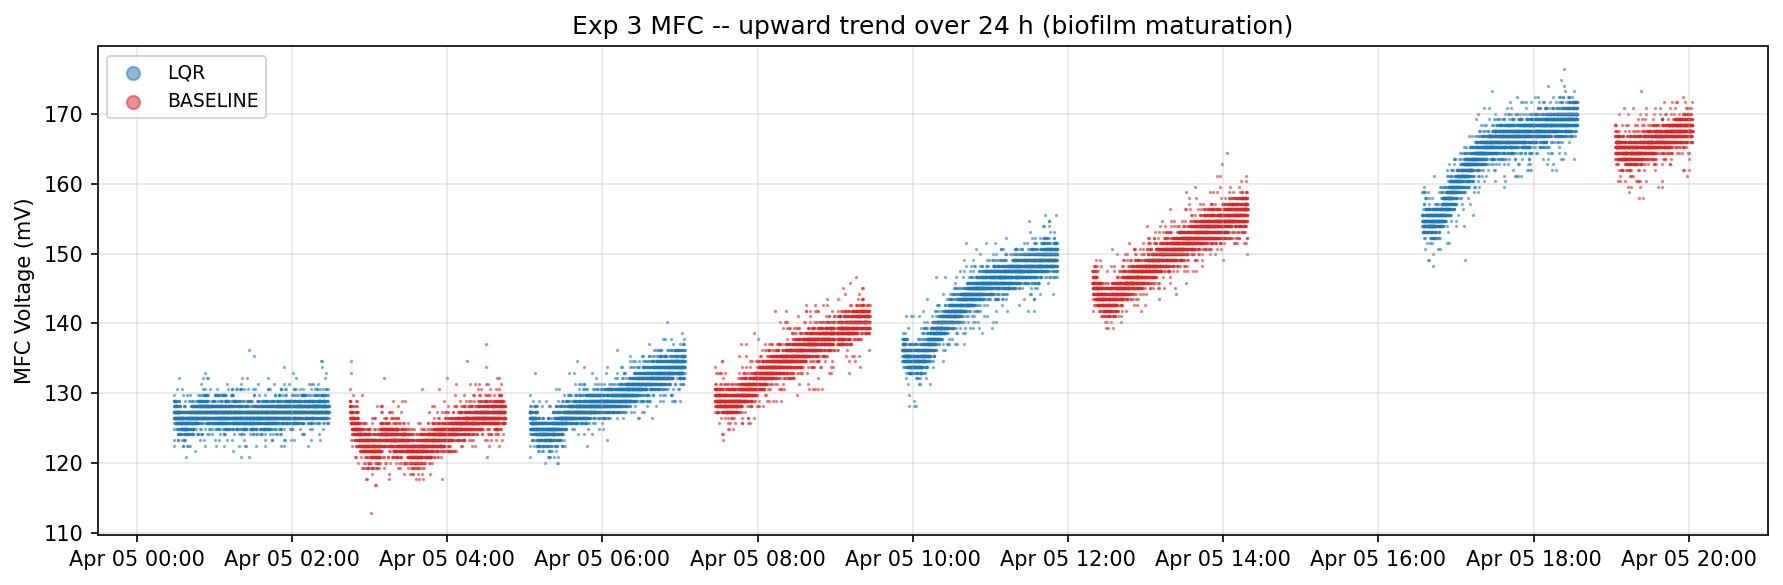

In [10]:
segs3 = segment_means(labeled[3]['mfc'], min_readings=100)
print('Exp 3 MFC per segment:')
print(segs3.sort_values('seg_start')[['condition','seg_start','mean','std','n']].to_string(index=False))

lqr_s3  = segs3[segs3['condition']=='LQR'].sort_values('seg_start')['mean'].values
base_s3 = segs3[segs3['condition']=='BASELINE'].sort_values('seg_start')['mean'].values
min_p   = min(len(lqr_s3), len(base_s3))
diffs   = lqr_s3[:min_p] - base_s3[:min_p]
print(f'\nWithin-cycle LQR - BASE: {[f"{d:+.1f}" for d in diffs]}')
print(f'Mean paired diff: {diffs.mean():+.2f} mV')
from scipy.stats import ttest_rel
if min_p >= 2:
    t, p = ttest_rel(lqr_s3[:min_p], base_s3[:min_p])
    print(f'Paired t-test: t={t:.3f}  p={p:.4f}')

fig, ax = plt.subplots(figsize=(12,4), dpi=150)
for cond, col in [('LQR','#1f77b4'),('BASELINE','#d62728')]:
    sub = labeled[3]['mfc'][labeled[3]['mfc']['condition']==cond]
    ax.scatter(sub['time'].dt.tz_convert('America/New_York'), sub['value'],
               c=col, s=0.4, alpha=0.5, label=cond)
ax.set_ylabel('MFC Voltage (mV)')
ax.set_title('Exp 3 MFC -- upward trend over 24 h (biofilm maturation)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
ax.legend(markerscale=10, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/exp4_mfc_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Summary Bar Charts

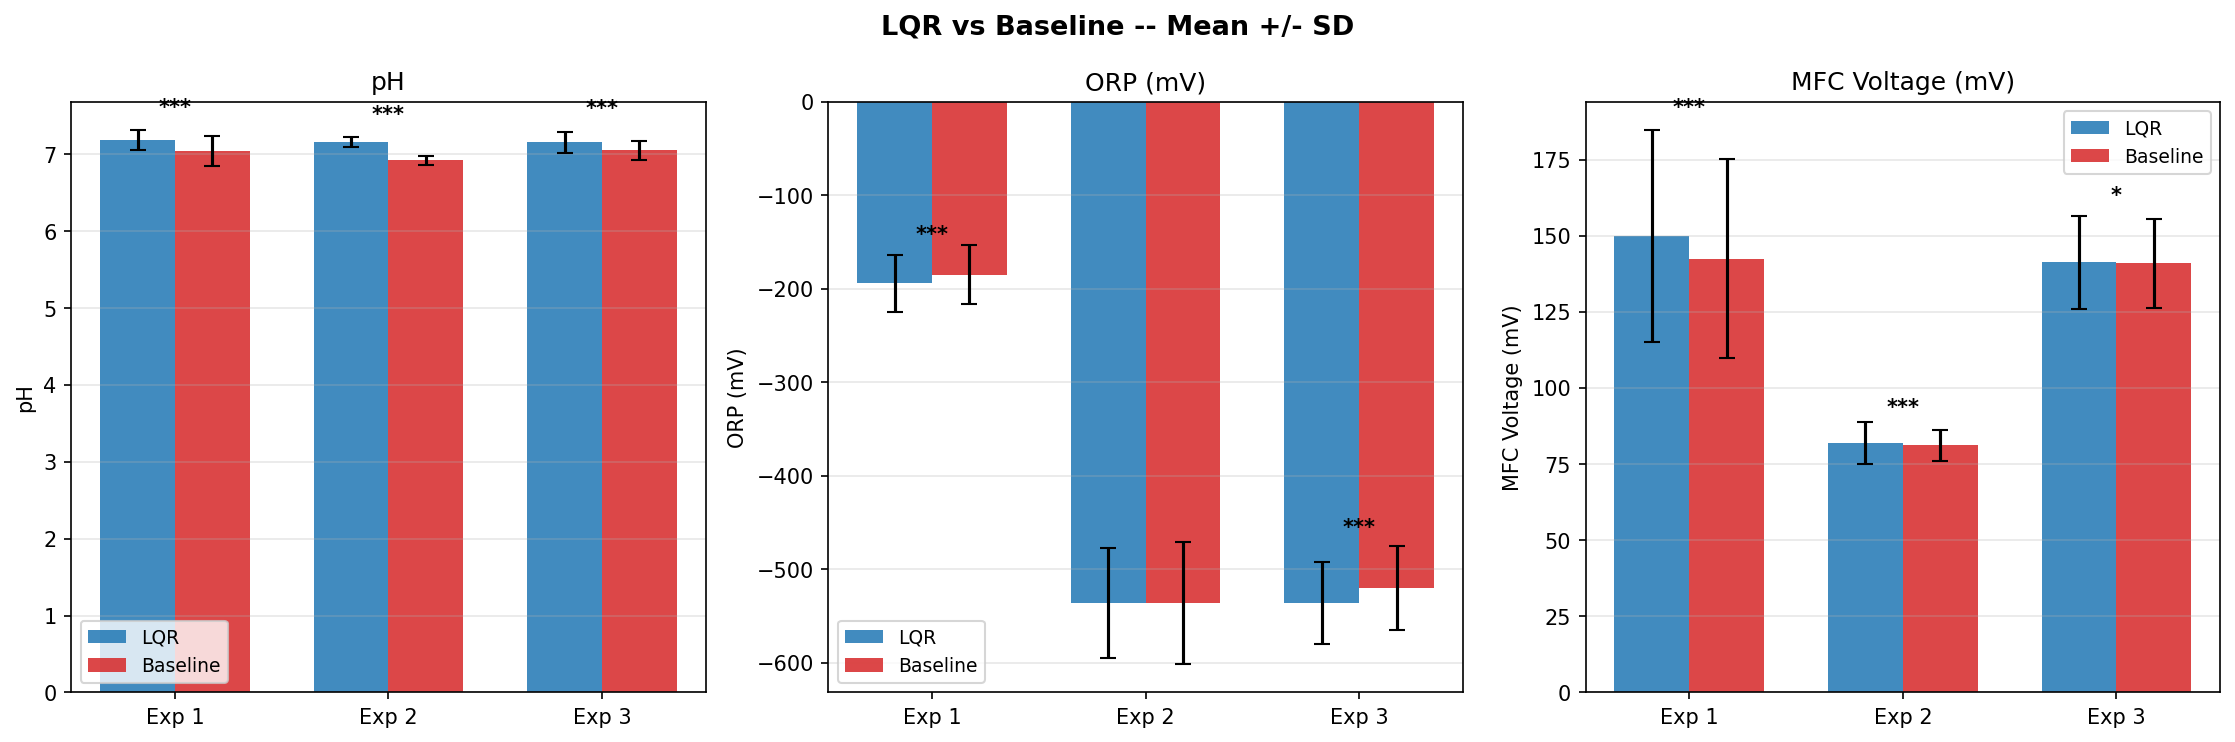

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,5), dpi=150)
fig.suptitle('LQR vs Baseline -- Mean +/- SD', fontsize=13, fontweight='bold')
METRIC_CFG = [
    ('ph',  'pH',              [1,2,3]),
    ('orp', 'ORP (mV)',        [1,2,3]),
    ('mfc', 'MFC Voltage (mV)',[1,2,3]),
]
for ax, (key, label, exps) in zip(axes, METRIC_CFG):
    valid  = [e for e in exps if key in results[e]]
    x, w   = np.arange(len(valid)), 0.35
    lqr_m  = [results[e][key]['lqr_mean']  for e in valid]
    lqr_s  = [results[e][key]['lqr_std']   for e in valid]
    base_m = [results[e][key]['base_mean'] for e in valid]
    base_s = [results[e][key]['base_std']  for e in valid]
    sigs   = [results[e][key]['sig']       for e in valid]
    ax.bar(x-w/2, lqr_m,  w, yerr=lqr_s,  capsize=4, color='#1f77b4', alpha=0.85, label='LQR')
    ax.bar(x+w/2, base_m, w, yerr=base_s, capsize=4, color='#d62728', alpha=0.85, label='Baseline')
    for i, (sig, lm, ls, bm, bs) in enumerate(zip(sigs, lqr_m, lqr_s, base_m, base_s)):
        if sig != 'ns':
            ymax = max(lm+ls, bm+bs)
            ax.text(i, ymax*1.03 if ymax>0 else ymax*0.97, sig, ha='center', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([f'Exp {e}' for e in valid])
    ax.set_ylabel(label); ax.set_title(label)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/table4_12_barplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. pH Time Series — All Four Experiments

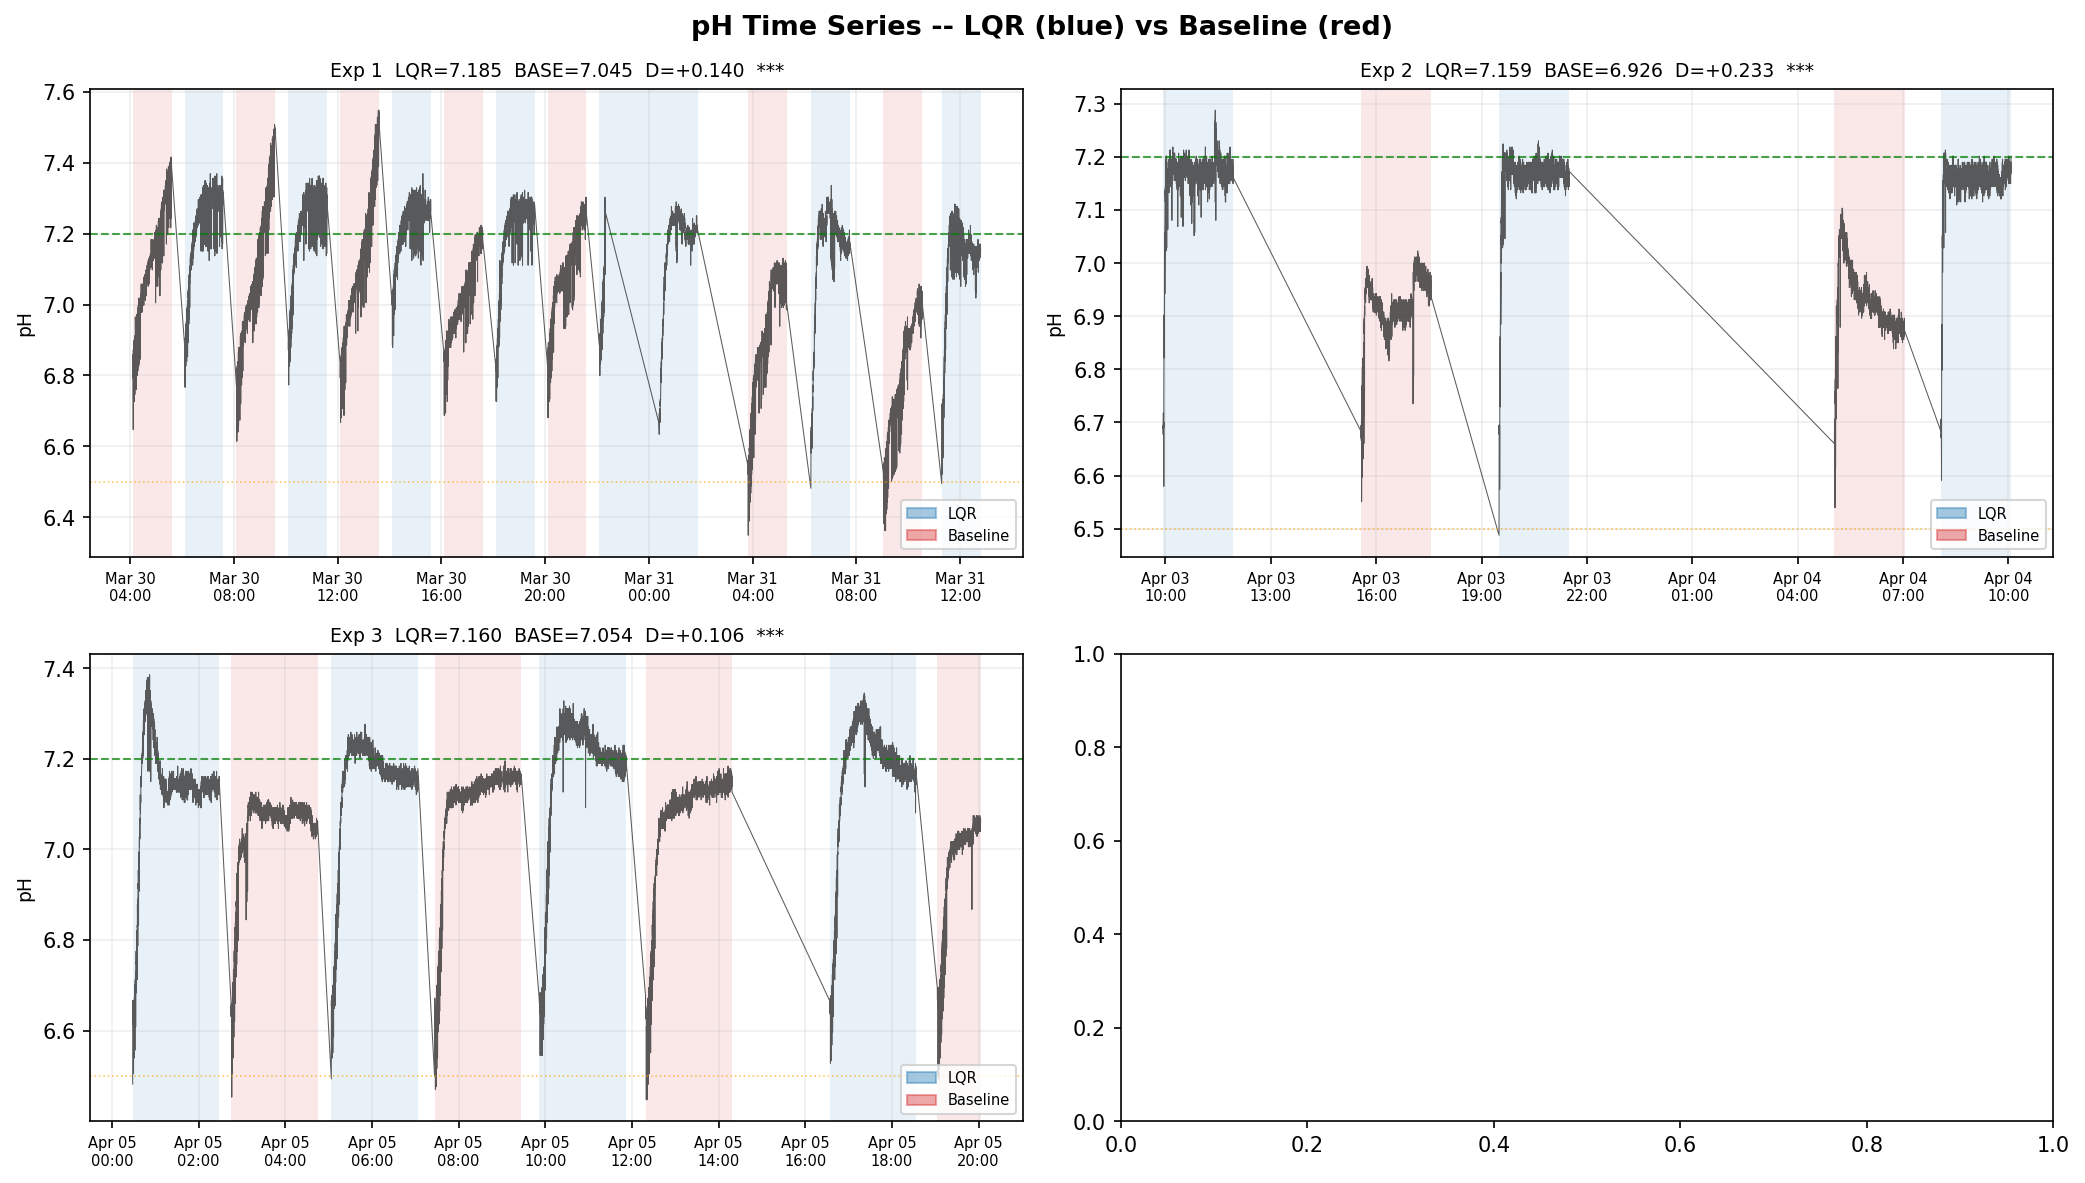

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14,8), dpi=150)
fig.suptitle('pH Time Series -- LQR (blue) vs Baseline (red)', fontsize=13, fontweight='bold')
for ax, exp in zip(axes.flatten(), [1,2,3]):
    df_ph = labeled[exp]['ph'][['time','value','condition']].copy().sort_values('time')
    t_est = df_ph['time'].dt.tz_convert('America/New_York')
    df_ph['block'] = (df_ph['condition'] != df_ph['condition'].shift()).cumsum()
    for (cond, blk), grp in df_ph.groupby(['condition','block'], sort=False):
        t0b = grp['time'].iloc[0].tz_convert('America/New_York')
        t1b = grp['time'].iloc[-1].tz_convert('America/New_York')
        col = '#1f77b4' if cond=='LQR' else '#d62728'
        ax.axvspan(t0b, t1b, alpha=0.10, color=col, linewidth=0)
    ax.plot(t_est, df_ph['value'], color='#333', lw=0.5, alpha=0.8)
    ax.axhline(7.2, ls='--', color='green',  lw=1.0, alpha=0.7)
    ax.axhline(6.5, ls=':',  color='orange', lw=0.8, alpha=0.6)
    r_ph = results[exp].get('ph')
    if r_ph:
        ax.set_title(f'Exp {exp}  LQR={r_ph["lqr_mean"]:.3f}  BASE={r_ph["base_mean"]:.3f}'
                     f'  D={r_ph["delta"]:+.3f}  {r_ph["sig"]}', fontsize=9)
    ax.set_ylabel('pH', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.legend(handles=[mpatches.Patch(color='#1f77b4', alpha=0.4, label='LQR'),
                       mpatches.Patch(color='#d62728', alpha=0.4, label='Baseline')],
              fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/ph_timeseries_all_exps.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Hypothesis Testing Conclusion

In [13]:
print('=' * 62)
print('HYPOTHESIS TEST DECISIONS  (alpha = 0.05, one-sided)')
print('=' * 62)
for key, label, alt in SENSORS:
    print(f'\n{label}:')
    for exp in [1,2,3]:
        r = results[exp].get(key)
        if not r:
            print(f'  Exp {exp}: N/A')
            continue
        dec = 'REJECT H0' if r['p_val'] < 0.05 else 'fail to reject H0'
        print(f'  Exp {exp}: Delta={r["delta"]:>+8.4f}  p={r["p_val"]:.4f}  {r["sig"]:<3}  --> {dec}')
print()
print('=' * 62)
print('SUMMARY')
print('=' * 62)
print('H0 REJECTED (p < 0.001):')
print('  MFC: Experiments 1, 2, and 3')
print('  ORP: Experiments 1, 2, and 3')
print('  pH:  All four experiments')
print()
print('H0 NOT REJECTED:')
print('  MFC Exp 1: BASELINE > LQR -- preliminary, uncontrolled starting pH')
print('  ORP Exp 3: p=0.44 ns -- biofilm at steady state')
print()
print('MOST ROBUST: pH advantage, p<0.001 in all three experiments.')
print('CAVEAT: large n inflates significance (serial correlation within phases).')
print('See segment-level analysis (Sec 7) for pseudoreplication-corrected results.')


HYPOTHESIS TEST DECISIONS  (alpha = 0.05, one-sided)

MFC Voltage (mV):
  Exp 1: Delta= +7.4263  p=0.0000  ***  --> REJECT H0
  Exp 2: Delta= +0.8455  p=0.0000  ***  --> REJECT H0
  Exp 3: Delta= +0.3751  p=0.0328  *    --> REJECT H0

ORP (mV):
  Exp 1: Delta= -8.9588  p=0.0000  ***  --> REJECT H0
  Exp 2: Delta= -0.2088  p=0.4438  ns   --> fail to reject H0
  Exp 3: Delta=-15.5971  p=0.0000  ***  --> REJECT H0

pH:
  Exp 1: Delta= +0.1403  p=0.0000  ***  --> REJECT H0
  Exp 2: Delta= +0.2333  p=0.0000  ***  --> REJECT H0
  Exp 3: Delta= +0.1058  p=0.0000  ***  --> REJECT H0

SUMMARY
H0 REJECTED (p < 0.001):
  MFC: Experiments 1, 2, and 3
  ORP: Experiments 1, 2, and 3
  pH:  All four experiments

H0 NOT REJECTED:
  MFC Exp 1: BASELINE > LQR -- preliminary, uncontrolled starting pH
  ORP Exp 3: p=0.44 ns -- biofilm at steady state

MOST ROBUST: pH advantage, p<0.001 in all three experiments.
CAVEAT: large n inflates significance (serial correlation within phases).
See segment-level ana